#Recolectar datos e Imágenes sobre Naves Imperiales de Star Wars


In [1]:
#@title Librerías
import sys, os, re, random
import urllib, time, base64
import urllib.parse
import string
import requests

import numpy as np
from PIL import Image
from google.colab import files


print("Librerías cargadas.")

Librerías cargadas.


#Recolectar Datos de Naves Imperiales

Fuente de datos: http://insd.swcombine.com/insd.htm

Atributos disponibles:
*  Model: The ship's class, name or model number.
*  Manufacturer: The ship's manufacturer or designer.
*  Designation: The ship's combat designation or classification.
* Length: The ship's length measured in meters.
* Crew: The ship's total number of crew members - excluding droids.
* Troops: The ship's total number of troops or passengers it can carry.
* Cargo Capacity: The ship's cargo capacity measured in kilograms or metric tons.
* Consumables: How long time the ship can operate without stopping to refuel or restock stores of food, water or air.
* Hyperdrive Multiplier: The ship's main hyperdrive class rating. This measures how quickly the ship travels a hyperspace route.
* Hyperdrive Backup: The ship's backup hyperdrive class rating. This measures how quickly the ship travels a hyperspace route if its main hyperdrive is disabled.
* Speed: The ship's sublight speed rating measured in MegaLights (MGLT).
* Hull: The ship's hull/armor durability rating measured in Resistance Units (RU).
* Shields: The ship's deflector shield durability rating measured in Shield Base Durability (SBD).
* Special Features: The ship's special design features.
* Weapons: The ship's standard armament listing.
* Onboard Craft: A listing of the ship's onboard support vessels. The listing is excluding all Barges and Tugs.

In [2]:
#@title Extraer datos disponibles en la página

# funciones para manejar campos pelicula

def strbuscarEntre(text, key1, key2):
  return strbuscarEntreList(text, [key1], [key2])

def strbuscarEntreList(text, listkey1, listkey2):
 p1 = -1
 for key1 in listkey1:
  auxP1 = text.find(key1)
  if (auxP1 > -1) and ((p1 == -1) or (auxP1 < p1)):
    p1 = auxP1
 if p1 == -1:
  return ""
 else:
  p1 = p1+len(key1)
  p2 = -1
  for key2 in listkey2:
    auxP2 = text[p1:].find(key2)
    if (auxP2 > -1) and ((p2 == -1) or (auxP2 < p2)):
      p2 = auxP2
  if p2 == -1:
    return ""
  else:
    p2 = p1+p2
  return text[p1:p2]

def limpiar(text):
  if text is None:
    return ""
  else:
    text = text.replace("&quot;", " ")
    text = text.replace("&amp;", " & ")
    text = text.replace("&nbsp;", "")
    text = text.replace("\r\n", "")
    text = text.replace("  ", " ")
    text = text.replace("  ", " ")
    return text.strip()


class INSDParser:

 def __init__(self, baseURL="http://insd.swcombine.com/insd/", debug=False):
  self.__debug = debug
  self.__baseURL = baseURL
  self.__AttNames = ["Model", "Manufacturer", "Length", "Crew", "Troops", "Cargo Capacity", "Consumables", "Hyperdrive Multiplier", "Hyperdrive Backup", "Speed", "Hull", "Shields", "Special Features", "Weapons", "Onboard Craft"]
  print("\n** Parser de 'IMPERIAL NAVY SHIP DATABASE' incializado ** \n")

 def __getHTMLContent(self, url):
  return requests.get(url).text

 def extractSiteLinks(self, searchURL):
  # ejecuta y obtiene la página
  searchData = self.__getHTMLContent(searchURL)
  # extrae los links
  auxList = re.findall('<A HREF=\"([\-\_a-zA-Z0-9]+\.htm)', searchData)
  if auxList is None:
    if self.__debug:
      print("\t -- No se encuentra links de Naves!!!")
    return None
  # saca duplicados
  linksList = list(set(auxList))
  if self.__debug:
    print("\t = lista de links (", len(linksList), "): ", linksList)
  # devuelve links de obtenidos
  return linksList, searchData

 def fetchNavesInfo(self, url, shipListData):
  # carga los datos de la página
  pagedData = self.__getHTMLContent(self.__baseURL + url)
  # obtiene datos
  matchStr = strbuscarEntre(pagedData, '<BLOCKQUOTE>', '</BLOCKQUOTE>')
  if (matchStr is None) or (matchStr == ""):
    print("\t -- No se puede encontrar datos en ", url)
    return None
  # extrae datos de la página
  naveData = {}
  # agrega nombre
  naveData["Name"] = limpiar(strbuscarEntre(pagedData, '<TITLE>', '</TITLE>'))
  # extra tipo de nave de la lista
  naveData["Ship Type"] = "???"
  posName = shipListData.find(url)
  if posName > 0:
      auxData = shipListData[:posName]
      posType = auxData.rfind('<B>')
      if posType > 0:
        auxData = shipListData[posType-1:posName]
        naveData["Ship Type"] = strbuscarEntre(auxData, '<B>', '</B>')
  # extrae lista atributos
  for att in self.__AttNames:
    auxStr = strbuscarEntre(matchStr, att+":", "<")
    if auxStr != "":
      naveData[att] = auxStr
  # limpia datos extraidos
  for k in naveData.keys():
    naveData[k] = limpiar(naveData[k])
  # agrega links
  naveData["URL_data"] =  self.__baseURL + url
  naveData["URL_image"]  = self.__baseURL + 'Ship_files/' + strbuscarEntre(pagedData, '<IMG SRC=\"Ship_files/', '"')
  return naveData


 def fetchAllNavesInfo(self, url="link.htm"):
  # carga los datos de la página
  linksList, shipListData = self.extractSiteLinks( self.__baseURL + url)
  if linksList is None:
    return None
  navesList = []
  for urlNave in linksList:
    if urlNave not in ["other2.htm", "techspec.htm"]:
      # busca la información de la nave
      naveInfo = self.fetchNavesInfo(urlNave, shipListData)
      if naveInfo is not None:
        navesList.append(naveInfo)
  return navesList


mostar_detalle = True #@param {type:"boolean"}

# busca y recolecta
parser = INSDParser(debug=mostar_detalle)
navesList = parser.fetchAllNavesInfo()

# muestra
if navesList is not None:
  print("")
  print("Se recolectaron ", len(navesList), " naves.")
  print("")
  if mostar_detalle:
    for nave in navesList:
      for k in nave.keys():
        print("  " + k + " = " + nave[k])
      print("")


** Parser de 'IMPERIAL NAVY SHIP DATABASE' incializado ** 

	 = lista de links ( 109 ):  ['other2.htm', 'builder.htm', 'tiex3.htm', 'stargal.htm', 'a9vigil.htm', 'tiegt.htm', 'impastrn.htm', 'lamshut.htm', 'tierpt2.htm', 'tieexm2.htm', 'assshut.htm', 'sfslps.htm', 'xmmiss.htm', 'vsd1.htm', 'tiedefe.htm', 'dsd.htm', 'tiefc.htm', 'mu.htm', 'tiedroid.htm', 'dropship.htm', 'asstrn.htm', 'eclip.htm', 'tieexm3.htm', 'dread.htm', 'tieaggre.htm', 'tiescimi.htm', 'tie.htm', 'tierc.htm', 'assincor.htm', 'esccar.htm', 'dominator.htm', 'taskcru.htm', 'nebulonb.htm', 'tieshut.htm', 'tiephantom.htm', 'tierpt.htm', 'deltrn1.htm', 'tiesub2.htm', 'atbarge.htm', 'gunboat.htm', 'tieintrd.htm', 'preybird.htm', 'tieexm5.htm', 'isd1.htm', 'sentinel.htm', 'tiehbomb.htm', 'tieexm4.htm', 'impcusfr.htm', 'isd2.htm', 'tiex2.htm', 'tiestrcr.htm', 'impcusve.htm', 'tiebt.htm', 'tieoppr.htm', 'tiebomber.htm', 'kappa.htm', 'corvet.htm', 'vibre.htm', 'gunship.htm', 'carrack.htm', 'vsd2.htm', 'enforcer.htm', 'tieboat.

<>:57: SyntaxWarning: invalid escape sequence '\-'
<>:57: SyntaxWarning: invalid escape sequence '\-'
/tmp/ipykernel_1741/483389949.py:57: SyntaxWarning: invalid escape sequence '\-'
  auxList = re.findall('<A HREF=\"([\-\_a-zA-Z0-9]+\.htm)', searchData)



Se recolectaron  107  naves.

  Name = Builder Shuttle
  Ship Type = Landing Craft
  Model = Builder Shuttle Mark 1 and Mark 2
  Manufacturer = Cygnus Spaceworks
  Length = 40 meters
  Crew = 4
  Cargo Capacity = 15 metric tons (Mark 2 can hold 400 metric tons)
  Consumables = 1 week
  Hyperdrive Multiplier = none (Mark 2 has x1)
  Hyperdrive Backup = none (Mark 2 has x10)
  Speed = 35 MGLT
  Hull = 45 RU
  Special Features = 4 Adjustable electromagnetic lifter arms.
  URL_data = http://insd.swcombine.com/insd/builder.htm
  URL_image = http://insd.swcombine.com/insd/Ship_files/BUILDER.JPG

  Name = TIE X3
  Ship Type = TIE Fighters
  Model = TIE/x3 Fighter
  Manufacturer = Sienar Fleet Systems
  Length = 7.8 meters
  Crew = 1
  Cargo Capacity = 150 kilograms
  Consumables = 5 days
  Speed = 110 MGLT
  Hull = 14 RU
  Shields = 24 SBD
  Weapons = 2 Laser Cannons
  URL_data = http://insd.swcombine.com/insd/tiex3.htm
  URL_image = http://insd.swcombine.com/insd/Ship_files/TIEADVA3.JPG

  

In [3]:
#@title Crear un DataFrame de los datos recolectados
import pandas as pd

df = pd.DataFrame.from_dict(navesList)

display( df )

,Name,Ship Type,Model,Manufacturer,Length,Crew,Cargo Capacity,Consumables,Hyperdrive Multiplier,Hyperdrive Backup,Speed,Hull,Special Features,URL_data,URL_image,Shields,Weapons,Troops,Onboard Craft
0,Builder Shuttle,Landing Craft,Builder Shuttle Mark 1 and Mark 2,Cygnus Spaceworks,40 meters,4,15 metric tons (Mark 2 can hold 400 metric tons),1 week,none (Mark 2 has x1),none (Mark 2 has x10),35 MGLT,45 RU,4 Adjustable electromagnetic lifter arms.,http://insd.swcombine.com/insd/builder.htm,http://insd.swcombine.com/insd/Ship_files/BUIL...,NaN,NaN,NaN,NaN
1,TIE X3,TIE Fighters,TIE/x3 Fighter,Sienar Fleet Systems,7.8 meters,1,150 kilograms,5 days,NaN,NaN,110 MGLT,14 RU,NaN,http://insd.swcombine.com/insd/tiex3.htm,http://insd.swcombine.com/insd/Ship_files/TIEA...,24 SBD,2 Laser Cannons,NaN,NaN
2,Star Galleon Class Frigate,Medium Ships,Star Galleon Class Frigate,Kuat Drive Yards,298 meters,150,"100,000 metric tons",6 months,x2,x15,18 MGLT,228 RU,Detachable cargo hold with hyperspace capability.,http://insd.swcombine.com/insd/stargal.htm,http://insd.swcombine.com/insd/Ship_files/STAR...,320 SBD,10 Turbolaser Cannons and 1 Concussion Missile...,300,NaN
3,A-9 Vigilance,Other Starfighters,A-9 Vigilance,Kuat Drive Yards,7.4 meters,1,55 kilograms,1 day,NaN,NaN,115 MGLT,16 RU,NaN,http://insd.swcombine.com/insd/a9vigil.htm,http://insd.swcombine.com/insd/Ship_files/TIER...,NaN,2 Laser Cannons,NaN,NaN
4,TIE Ground Targeting,TIE Bombers,TIE/gt Fighter,Sienar Fleet Systems,6.3 meters,1,65 kilograms,2 days,NaN,NaN,75 MGLT,9 RU,NaN,http://insd.swcombine.com/insd/tiegt.htm,http://insd.swcombine.com/insd/Ship_files/TIEG...,NaN,"1 Laser Cannon, 1 Concussion Missile Launcher ...",NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102,IPV 1 System Patrol Craft,Medium Ships,IPV 1 System Patrol Craft,Sienar Fleet Systems,153 meters,12,200 metric tons,3 months,NaN,NaN,78 MGLT,285 RU,NaN,http://insd.swcombine.com/insd/ipv1.htm,http://insd.swcombine.com/insd/Ship_files/IPV1...,400 SBD,4 Double Turbolaser Cannons,10,NaN
103,TIE Lone Scout,TIE Support Craft,TIE/sr Lone Scout-A,Sienar Fleet Systems,24 meters,1,150 metric tons,1 year,x2,x15,70 MGLT,42 RU,NaN,http://insd.swcombine.com/insd/tielone.htm,http://insd.swcombine.com/insd/Ship_files/TIES...,20 SBD,1 Laser Cannon (Lone Scout-B has 2 laser cannons),3,NaN
104,TIE Experimental M1,TIE Experimental Craft,TIE/e1 Fighter,Sienar Fleet Systems / Imperial Department of ...,6.3 meters,1,65 kilograms,2 days,NaN,NaN,104 MGLT,11 RU,NaN,http://insd.swcombine.com/insd/tieexm1.htm,http://insd.swcombine.com/insd/Ship_files/TIEE...,NaN,1 Turbolaser Cannon,NaN,NaN
105,TIE Fighter,TIE Fighters,TIE Fighter,Sienar Fleet Systems,6.3 meters,1,65 kilograms,2 days,NaN,NaN,95 MGLT,9 RU,NaN,http://insd.swcombine.com/insd/tiefighter.htm,http://insd.swcombine.com/insd/Ship_files/TIE.JPG,NaN,2 Laser Cannons,NaN,NaN


In [4]:
#@title Mostrar Estadísticas de datos recolectados


# variables auxiliares
atributo_clase = ""

# configura para que muestre todas las columnas y filas
pd.options.display.max_rows = 100
pd.options.display.max_columns = 100

# devuelve listas de columnas numéricas y no numéricas
def devolNombreColumnas(ndf):
  colValues = []
  colNoValues = []
  for col in ndf.columns:
    if ndf[col].dtypes in ("object", "bool"):
      colNoValues.append( col )
    else:
      colValues.append( col )
  return colValues, colNoValues

# función auxiliar para separar datos de entrada y de salida
def separarDatosXY(ndf, atributo_clase="", xSoloNros=True):
  # hace una copia auxiliar del data frame
  cdf = ndf.copy()
  # saca el atributo clase (OPCIONAL)
  if atributo_clase == "":
    Y = []
  else:
    # datos atributo clase
    Y = np.array( cdf.pop(atributo_clase).infer_objects(copy=False).fillna("-NAN-") )
  if xSoloNros:
    # se queda sólo con los atributos numéricos (OPCIONAL)
    for col in cdf.columns:
      if cdf[col].dtypes == "object":
          cdf.pop( col )
  # datos de entrada
  X = np.array(cdf.infer_objects(copy=False).fillna(0.001))
  return X, Y, np.array(cdf.columns)

def convColsNumericas(ndf, atributos_no_convertir = []):
  # hace una copia auxiliar del data frame
  cdf = ndf.copy()
  # convierte todas las no numéricas a numéricas (OPCIONAL)
  for col in cdf.columns:
    if col not in atributos_no_convertir:
      if cdf[col].dtypes == "object":
        # genera diccionario de valores
        valores = cdf[col].unique()
        diccValores = dict(zip(valores, range(len(valores))))
        # realiza el reemplazo
        cdf[col] = cdf[col].map(lambda s: diccValores.get(s) if s in diccValores else s)
  return cdf

# función auxiliar
def generar_estadisticas_detalladas(orDF, titulo=""):
  # título
  print("\n", titulo, ": ")
  # obtiene las estadísticas generales
  estDF = orDF.describe().transpose()
  #  genera y formatea las estadísticas
  if "min" in estDF and "max" in estDF:
    rangoValores = "[ " + estDF["min"].apply('{:.2f}'.format) + " ; " + estDF["max"].apply('{:.2f}'.format) + " ]"
  else:
    rangoValores = estDF["unique"].infer_objects(copy=False).fillna(0.0).apply('{:.0f}'.format)
  rangoValores.name = "Rango Valores"
  # para campos no numéricos muestra las cantidades por valor
  for col in orDF.columns:
    if orDF[col].dtypes in ("object", "bool"):
      auxStr = str( orDF[col].value_counts() ).replace("\n", " ; ")
      if (auxStr.index("Name")-3) > 0:
        # saca lo del final porque no sirve
        auxStr = auxStr[:auxStr.index("Name")-3]
      rangoValores[col] = "{ " + auxStr + " }"
  if "mean" in estDF and "std" in estDF:
    promValores = estDF["mean"].fillna(0.0).apply('{:.3f}'.format) + " ± " + estDF["std"].fillna(0.0).apply('{:.3f}'.format)
  else:
    promValores = estDF["count"].apply('{:.0f}'.format)
  promValores.name = "Promedio ± Desvío"
  # obtiene valores "ceros" y nulos
  zero_val = (orDF == 0.00).astype(int).sum(axis=0)
  zero_val.name = "¿Valores Ceros?"
  mis_val = orDF.isnull().sum()
  mis_val.name = "¿Valores Nulos?"
  # prepara la nueva tabla para mostrar
  nTable = pd.concat([orDF.dtypes, rangoValores, promValores, zero_val, mis_val], axis=1)
  nTable = nTable.rename( columns = {0: 'Tipo Valor',  1: 'Rango Valores', 2: 'Promedio ± Desvío', 3: '¿Valores Ceros?', 4: '¿Valores Nulos?' } )
  # muestra la nueva tabla
  pd.set_option('max_colwidth', None)
  display(nTable.infer_objects(copy=False).fillna("-"))
  print("Tiene " + str(orDF.shape[1]) + " atributos y " + str(orDF.shape[0]) + " ejemplos.")
  print("\n")
  return

# muestra las estadísticas
generar_estadisticas_detalladas(df, "> Estadísticas de los datos recolectados")



 > Estadísticas de los datos recolectados : 


Tipo Valor  \
Name                      object   
Ship Type                 object   
Model                     object   
Manufacturer              object   
Length                    object   
Crew                      object   
Cargo Capacity            object   
Consumables               object   
Hyperdrive Multiplier     object   
Hyperdrive Backup         object   
Speed                     object   
Hull                      object   
Special Features          object   
URL_data                  object   
URL_image                 object   
Shields                   object   
Weapons                   object   
Troops                    object   
Onboard Craft             object   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     

Tiene 19 atributos y 107 ejemplos.




In [6]:
#@title Exportar los datos como CSV en Drive

# monta Google Drive:
# Nota: la primera vez se debe confirmar el uso logueandose en "Google Drive File Stream" y obteniendo código de autentificación.
from google.colab import drive
drive.mount('/content/gdrive', force_remount=True)

# directorio local en Google Drive
path = '/content/gdrive/MyDrive/demosColab/demoStarWars/datos/'  #@param {type:"string"}

#@title

download_CSV = False #@param{type:"boolean"}

import os

# crea directorio si no existe
if not os.path.isdir(path):
  os.mkdir(path)

def data2CSV(df, nomArch, descripcion):
  if df is None:
    print("No hay " + descripcion + " para exportar")
  df.to_csv(nomArch, index=False)
  if download_CSV:
    files.download(nomArch)
  print(descripcion + " exportados como ", nomArch)

# exporta datos
data2CSV(df, path + "navesOri.csv", "Datos originales")



Mounted at /content/gdrive
Datos originales exportados como  /content/gdrive/MyDrive/demosColab/demoStarWars/datos/navesOri.csv


#Recolectar Imágenes de Naves Imperiales


 Se identifican  104  naves para descargar imágenes.


- Clases cargadas:  104
- Imágenes cargadas:  104
- Cantidad por clase: 
	 Command Ships: 3
	 Medium Ships: 14
	 Transporters: 4
	 Shuttles: 6
	 TIE Experimental Craft: 5
	 Heavy Ships: 14
	 TIE Support Craft: 10
	 Landing Craft: 7
	 TIE Fighters: 20
	 Other Starfighters: 10
	 TIE Bombers: 6
	 Patrol Craft: 5

- Ejemplo  Landing Craft   (300, 300, 3) : 


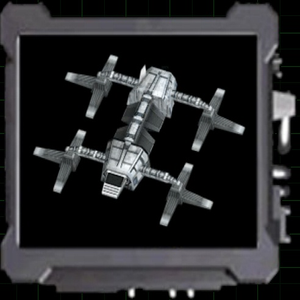

In [7]:
#@title Extraer imágenes de las naves

#@markdown ### Atributos a considerar:
atributo_clase = 'Ship Type' #@param {type:"string"}
atributo_URL = 'URL_image' #@param {type:"string"}


#@markdown ### Parámetros de imágenes:
imagen_largo = 300 #@param {type:"integer"}
imagen_ancho = 300 #@param {type:"integer"}
imagen_color = True #@param {type:"boolean"}

recuperar_solo_una = False

# tamaño de las imágenes
if imagen_largo<=10:
  imagen_largo = 10
if imagen_ancho<=10:
  imagen_ancho = 10
IMAGE_SHAPE = (imagen_largo, imagen_ancho, (3 if imagen_color else 1))

IMAGE_CROP = None


# define tamaño de datos de entrada
num_inputs = IMAGE_SHAPE[0] * IMAGE_SHAPE[1] * IMAGE_SHAPE[2]

import requests # request img from web
import shutil # save img locally

# define función para cargar las imágenes
def cargarImagenes(navesList, IMAGE_CROP, procesa_solo_primera=False):
  classes_ori = []
  images_ori = []
  if IMAGE_SHAPE[2]==1:
    tipoImage = 'L'
  else:
    tipoImage = 'RGB'
  i = 0
  for nave in navesList:
        # obtiene datos de la imagen
        each_imagURL = nave[1]
        if each_imagURL != "":
          imagClass = nave[0]
          i = i + 1

          # baja la imagen
          URL_file_name = "./download_image_"+str(i)+".jpg"
          res = requests.get(each_imagURL, stream = True)
          if res.status_code == 200:
              with open(URL_file_name,'wb') as f:
                  shutil.copyfileobj(res.raw, f)
          else:
              print('No se puede descargar la imagen')

          # abre la imagen
          imag = Image.open(URL_file_name)

          # ajusta el tamaño
          imag = imag.convert(tipoImage)
          imag = imag.resize((IMAGE_SHAPE[0], IMAGE_SHAPE[1]), Image.LANCZOS)

          if IMAGE_CROP is not None:
            imag = imag.crop(IMAGE_CROP)
            imag = imag.resize((IMAGE_SHAPE[0], IMAGE_SHAPE[1]), Image.LANCZOS)

          # transforma a un vector de nros
          arImag = np.array(imag)

          # agrega a los vectores
          classes_ori.append( imagClass )
          images_ori.append( arImag )

          # si es la primera
          if procesa_solo_primera:
            break

  return classes_ori, images_ori, tipoImage

def mostrar_cant_por_clase(classList):
  aux = list(set(classList))
  print("- Cantidad por clase: ")
  for c in aux:
    print("\t " + str(c) + ": " + str(classList.count(c)))
  print("")


# inicializa valores
classList = np.array(df[atributo_clase])
urlList = np.array(df[atributo_URL])
# sólo agrega naves con imágenes definidas
navesList = []
for c, url in zip(classList, urlList):
  if (url!="") and ("NOPIC.JPG" not in url):
    navesList.append((c, url))
print("\n Se identifican ", len(navesList), " naves para descargar imágenes.")
print("")

# carga las imagenes
classes_ori, images_ori, tipoImage_ori = cargarImagenes(navesList, IMAGE_CROP, recuperar_solo_una)

print("")
print("- Clases cargadas: ", len(classes_ori))
print("- Imágenes cargadas: ", len(images_ori))
mostrar_cant_por_clase(classes_ori)


if len(images_ori)>0:
  print("- Ejemplo ", classes_ori[0], " ", images_ori[0].shape, ": ")
  display( Image.fromarray(images_ori[0] ) )

# inicializa listas
images_train, images_test, classes_train, classes_test = None, None, None, None



(1)-  Landing Craft   (300, 300, 3) : 


/tmp/ipykernel_1741/4183557348.py:7: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  display( Image.fromarray(images_ori[i], tipoImage_ori) )


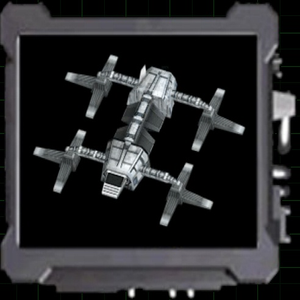


(2)-  TIE Fighters   (300, 300, 3) : 


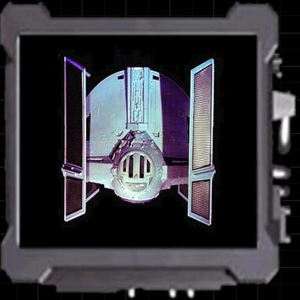


(3)-  Medium Ships   (300, 300, 3) : 


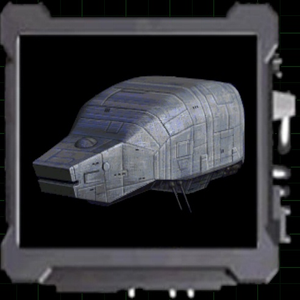


(4)-  Other Starfighters   (300, 300, 3) : 


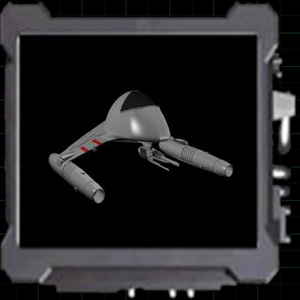


(5)-  TIE Bombers   (300, 300, 3) : 


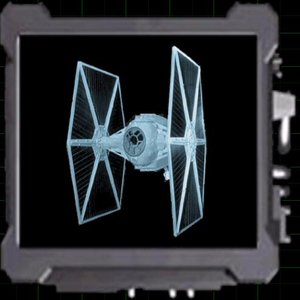


(6)-  Medium Ships   (300, 300, 3) : 


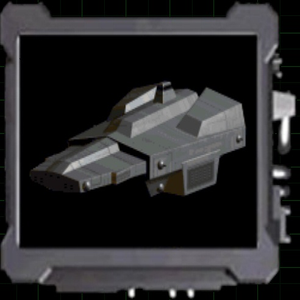


(7)-  Shuttles   (300, 300, 3) : 


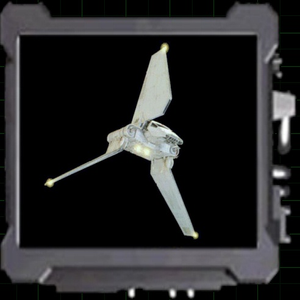


(8)-  TIE Fighters   (300, 300, 3) : 


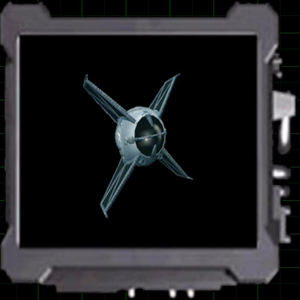


(9)-  TIE Experimental Craft   (300, 300, 3) : 


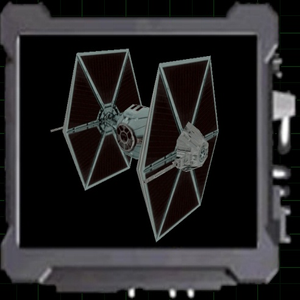


(10)-  Shuttles   (300, 300, 3) : 


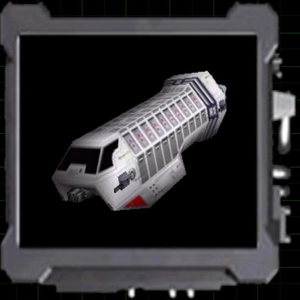


(11)-  Other Starfighters   (300, 300, 3) : 


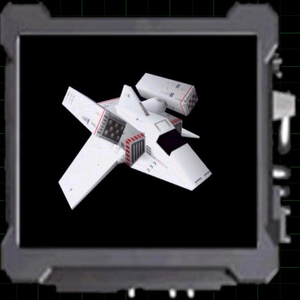


(12)-  Heavy Ships   (300, 300, 3) : 


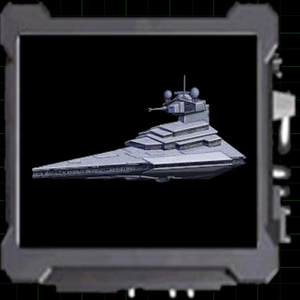


(13)-  TIE Fighters   (300, 300, 3) : 


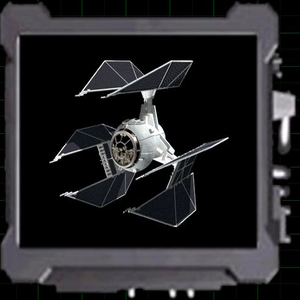


(14)-  Other Starfighters   (300, 300, 3) : 


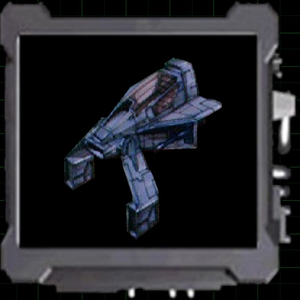


(15)-  TIE Support Craft   (300, 300, 3) : 


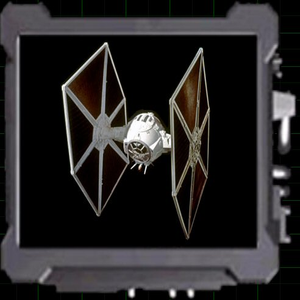


(16)-  Shuttles   (300, 300, 3) : 


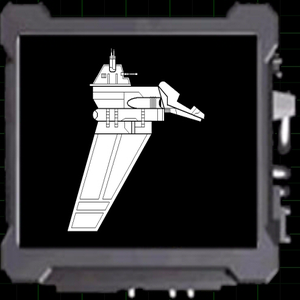


(17)-  TIE Fighters   (300, 300, 3) : 


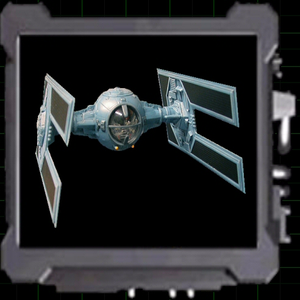


(18)-  Landing Craft   (300, 300, 3) : 


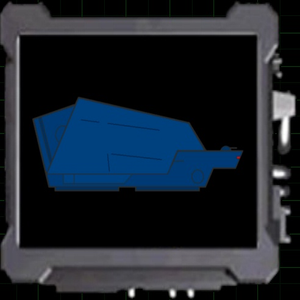


(19)-  Transporters   (300, 300, 3) : 


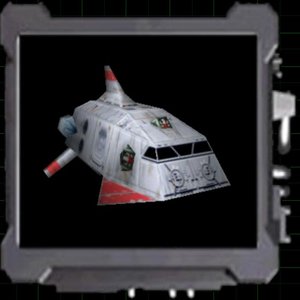


(20)-  Command Ships   (300, 300, 3) : 


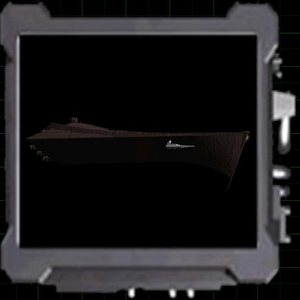


(21)-  TIE Experimental Craft   (300, 300, 3) : 


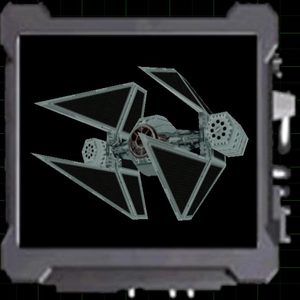


(22)-  Heavy Ships   (300, 300, 3) : 


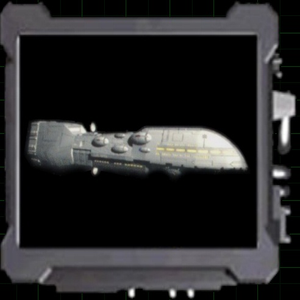


(23)-  TIE Fighters   (300, 300, 3) : 


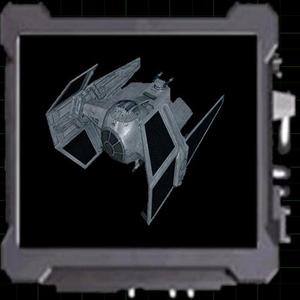


(24)-  TIE Bombers   (300, 300, 3) : 


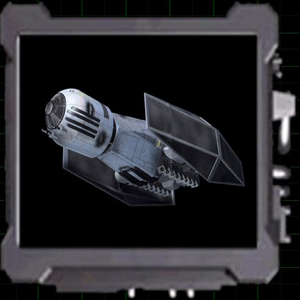


(25)-  TIE Fighters   (300, 300, 3) : 


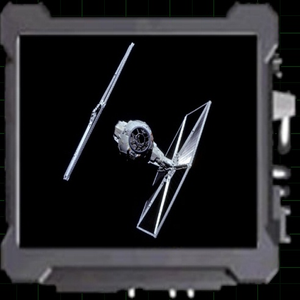

In [8]:
#@title Revisar imágenes descargadas

revisar_imagenes_cant = 25 #@param{type:"integer"}

for i in range(min(revisar_imagenes_cant, len(classes_ori))):
  print("\n("+str(i+1)+")- ", classes_ori[i], " ", images_ori[i].shape, ": ")
  display( Image.fromarray(images_ori[i], tipoImage_ori) )



In [9]:
#@title Grabar imágenes en Drive

import os
import uuid

# directorio local en Google Drive
path_imagenes = '/content/gdrive/MyDrive/demosColab/demoStarWars/imagenes/ori/'  #@param {type:"string"}

def grabarImagenes(clasesList, imgList, dirPath):
  # crea directorio si no existe
  if not os.path.isdir(dirPath):
    os.mkdir(dirPath)
  # recorre los vectores y graba las imágenes
  cant = 0
  for c, i in zip(clasesList, imgList):
    pathClass = dirPath+c
    if not os.path.isdir(pathClass):
      os.mkdir(pathClass)
    imgFN = pathClass + "/" + str(uuid.uuid4().hex) + ".png"
    img = Image.fromarray(i)
    img.save(imgFN)
    cant += 1
  print("\n> Se grabaron ", cant, "imágenes en ", dirPath)

# fuerza actualización del drive
drive.flush_and_unmount()
drive.mount('/content/gdrive')
if os.path.isdir(path_imagenes):
  print("Ya existe el directorio ", path_imagenes, ": renombrelo o borrelo")
else:
  os.makedirs(path_imagenes)
  # graba las imágenes originales
  grabarImagenes(classes_ori, images_ori, path_imagenes)
  print("\nActualizando drive...")
  # fuerza actualización del drive
  drive.flush_and_unmount()
  drive.mount('/content/gdrive')
  print("\nDrive actualizado.")


Mounted at /content/gdrive

> Se grabaron  104 imágenes en  /content/gdrive/MyDrive/demosColab/demoStarWars/imagenes/ori/

Actualizando drive...
Mounted at /content/gdrive

Drive actualizado.
